In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

zip_path = '/content/drive/MyDrive/ML_Assignment/xray_dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/xray_data')

print("Extraction done!")

Extraction done!


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

custom_aug = models.Sequential([
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.12),
], name="custom_aug")

train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/xray_data/train',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/xray_data/val',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/xray_data/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [7]:
import os

normal_count = len(os.listdir('/content/xray_data/train/NORMAL'))
pneumonia_count = len(os.listdir('/content/xray_data/train/PNEUMONIA'))
total = normal_count + pneumonia_count

class_weight = {
    0: total / (2 * normal_count),
    1: total / (2 * pneumonia_count)
}
print("NORMAL count:", normal_count, "| PNEUMONIA count:", pneumonia_count)
print("Class weights:", class_weight)

NORMAL count: 1341 | PNEUMONIA count: 3875
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [8]:
train_dir = '/content/xray_data/train'
val_dir = '/content/xray_data/val'
test_dir = '/content/xray_data/test'

img_size = (150, 150)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [9]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [15]:
base_effnet = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_effnet.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = custom_aug(inputs)
x = base_effnet(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs, name="XRay_EfficientNet")

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "XRay_EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_aug (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,136,740 (15.78 MB)

 Trainable params: 84,609 (330.50 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [16]:
custom_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        factor=0.3,
        patience=2
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=custom_callbacks
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 56s 234ms/step - accuracy: 0.8963 - auc: 0.9669 - loss: 0.2362 - precision: 0.9722 - recall: 0.8857 - val_accuracy: 0.8125 - val_auc: 1.0000 - val_loss: 0.3660 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 224ms/step - accuracy: 0.9239 - auc: 0.9797 - loss: 0.1821 - precision: 0.9780 - recall: 0.9182 - val_accuracy: 0.8750 - val_auc: 0.9844 - val_loss: 0.3295 - val_precision: 0.8000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 218ms/step - accuracy: 0.9340 - auc: 0.9835 - loss: 0.1601 - precision: 0.9820 - recall: 0.9283 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.1618 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 214ms/step - accuracy: 0.9352 - auc: 0.9839 - loss: 0.1595 - precision: 0.9812 - recall: 0.9306 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 

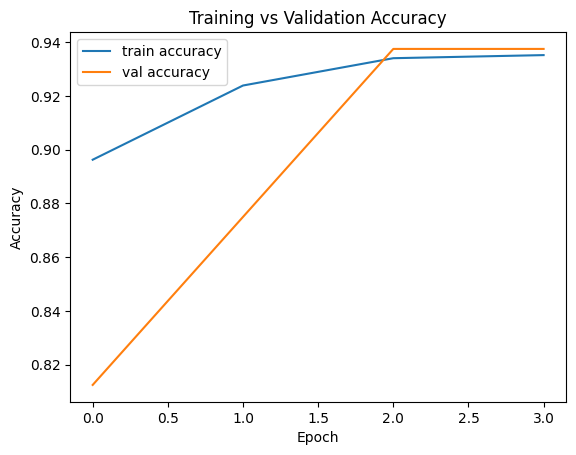

In [17]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [22]:
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.8542 - auc: 0.9369 - loss: 0.3459 - precision: 0.8405 - recall: 0.9462
Test Loss: 0.3459
Test Accuracy: 0.8542


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
              precision    recall  f1-score   support

      NORMAL       0.89      0.70      0.78       234
   PNEUMONIA       0.84      0.95      0.89       390

    accuracy                           0.85       624
   macro

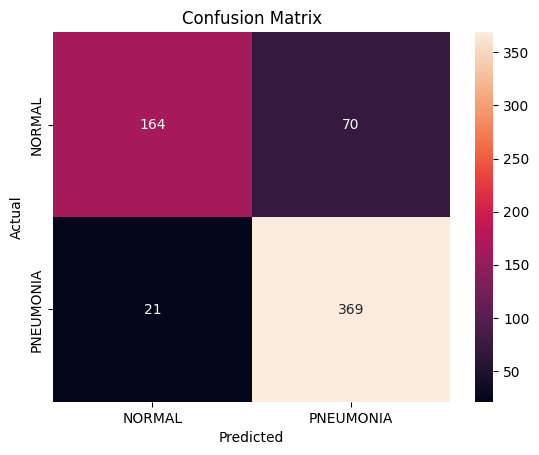

In [23]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((preds.flatten() > 0.5).astype(int))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:
model.save('/content/drive/MyDrive/ML_Assignment/xray_cnn_model.h5')

In [21]:
base_effnet.trainable = True

for layer in base_effnet.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weight,
    callbacks=custom_callbacks
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 248ms/step - accuracy: 0.8800 - auc: 0.9360 - loss: 0.3449 - precision: 0.9396 - recall: 0.8960 - val_accuracy: 0.8125 - val_auc: 0.9688 - val_loss: 0.2523 - val_precision: 0.7778 - val_recall: 0.8750 - learning_rate: 1.0000e-05
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 220ms/step - accuracy: 0.9016 - auc: 0.9638 - loss: 0.2458 - precision: 0.9654 - recall: 0.8999 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.2237 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 233ms/step - accuracy: 0.8993 - auc: 0.9637 - loss: 0.2512 - precision: 0.9676 - recall: 0.8945 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.2152 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 3.0000e-06
